In [1]:
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data
import pandas as pd
import numpy as np
import seaborn as sns
import anndata
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from tqdm import tqdm
import re
import logging

import scanpy as sc
import anndata as ad

import anndata2ri
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import pandas2ri

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython



Error importing in API mode: ImportError("dlopen(/Users/Amith/miniforge3/envs/abc_atlas/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <1984CB9B-890E-3855-A246-270AC6AC4C62> /Users/Amith/miniforge3/envs/abc_atlas/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


### **1. Using the Cache**

In [2]:
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

/Users/Amith/miniforge3/envs/abc_atlas/lib/python3.11/site-packages/abc_atlas_access/abc_atlas_cache/cloud_cache.py:679: OutdatedManifestWarning: You are loading releases/20251031/manifest.json. A more up to date version of the dataset -- releases/20260331/manifest.json -- exists online. To see the changes between the two versions of the dataset, run
type.compare_manifests('releases/20251031/manifest.json', 'releases/20260331/manifest.json')
To load another version of the dataset, run
type.load_manifest('releases/20260331/manifest.json')
  warnings.warn(msg, OutdatedManifestWarning)


'releases/20251031/manifest.json'

In [3]:
# See what methods are available on the cache object
print(dir(abc_cache))

# Check the actual source
import abc_atlas_access
print(abc_atlas_access.__file__)  # find where it's installed, then read the source

['MANIFEST_COMPATIBILITY', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_default_bucket_name', '_get_directory_files', '_get_local_path', '_local', '_ui_class_name', '_warn_directory_size', 'cache', 'compare_manifests', 'current_manifest', 'from_cache_dir', 'from_local_cache', 'from_s3_cache', 'get_data_path', 'get_directory_expression_matrices', 'get_directory_expression_matrix_size', 'get_directory_image_volume_size', 'get_directory_image_volumes', 'get_directory_mapmycells', 'get_directory_mapmycells_size', 'get_directory_metadata', 'get_directory_metadata_size', 'get_directory_size_by_kind', 'get_file_path', 'get_metadata_dataframe', 'get_metadata_path', 'latest_downloade

### **2. Dataset Assembly**

In [4]:
# Donwloads raw expression matrix from ageing dataset
h5ad_path = abc_cache.get_data_path(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='Zeng-Aging-Mouse-10Xv3/raw'
)
print(h5ad_path)

/Users/Amith/Documents/Documents – Viji’s MacBook Pro/Work/LIDo PhD/Main Project/data/abc_atlas/expression_matrices/Zeng-Aging-Mouse-10Xv3/20241130/Zeng-Aging-Mouse-10Xv3-raw.h5ad


In [5]:
# Load the cell metadata.
cell = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cell_metadata',
    dtype={'cell_label': str,
           'wmb_cluster_alias': 'Int64'}
)
cell.set_index('cell_label', inplace=True)

cell_colors = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cell_annotation_colors'
).set_index('cell_label')

cluster_info = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cluster'
).set_index('cluster_alias')

cell_cluster_mapping = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-WMB-taxonomy',
    file_name='cell_cluster_mapping_annotations'
).set_index('cell_label')
cell_cluster_mapping.head()

# Join on the cell_label index.
cell_extended = cell.join(cell_cluster_mapping, rsuffix='_cl_map')
cell_extended = cell_extended.join(cell_colors, rsuffix='_cl_colors')
# Join the cluster information in by joining on the Aging dataset's cluster_alias column.
cell_extended = cell_extended.join(cluster_info, on='cluster_alias', rsuffix='_cl_info')

# Quick run through to drop duplicated columns
drop_cols = []
for col in cell_extended.columns:
    if col.endswith(('_cl_map', '_cl_colors', '_cl_info')):
        drop_cols.append(col)
cell_extended.drop(columns=drop_cols, inplace=True)

# The dataset is sorted on cell_label by default, this causes some plotting weirdness
# due to all "adult" cells being first in the order. Below we scrabble the DataFrame
# to better reproduce plots from the paper.
cell_extended = cell_extended.sample(frac=1, random_state=12345)

cell_extended.head()

,cell_barcode,gene_count,umi_count,doublet_score,x,y,cluster_alias,cell_in_wmb_study,wmb_cluster_alias,library_label,...,proportion_adult_cells,proportion_aged_cells,odds_ratio,log2_odds_ratio,cluster_age_bias,max_region_of_interest_color,cluster_age_bias_color,neurotransmitter_combined_label,neurotransmitter_label,neurotransmitter_color
cell_label,,,,,,,,,,,,,,,,,,,,,
GCCTGTTGTGAATTAG-135_B01,GCCTGTTGTGAATTAG,6777,37834.0,0.200000,-1.185296,1.881103,278,True,1079,L8TX_190716_01_D07,...,0.577949,0.422051,1.013716,0.019653,unassigned,#80CDF8,#DADEDF,GABA,GABA,#FF3358
TCCGAAAGTGAAGCGT-761_A04,TCCGAAAGTGAAGCGT,3396,9585.0,0.030303,14.007499,-0.220336,817,False,<NA>,L8TX_210805_01_H01,...,0.454494,0.545506,1.046448,0.065500,unassigned,#8599CC,#DADEDF,No-NT,No-NT,#666666
TTACCATGTCGTGGTC-327_A06,TTACCATGTCGTGGTC,4294,10527.0,0.020000,6.550781,-1.378886,804,False,<NA>,L8TX_200813_01_H10,...,0.370570,0.629430,1.741208,0.800089,unassigned,#80C0E2,#DADEDF,No-NT,No-NT,#666666
ACGGGTCGTACGAGCA-385_D06,ACGGGTCGTACGAGCA,2943,6957.0,0.000000,13.650183,0.289086,817,False,<NA>,L8TX_201008_01_A12,...,0.454494,0.545506,1.046448,0.065500,unassigned,#8599CC,#DADEDF,No-NT,No-NT,#666666
CTTAGGATCTGTCCCA-301_B04,CTTAGGATCTGTCCCA,7907,47406.0,0.037037,6.583878,-10.639808,152,False,<NA>,L8TX_200723_01_B10,...,0.403409,0.596591,0.587232,-0.767999,unassigned,#72D569,#DADEDF,Glut,Glut,#2B93DF


In [6]:
# Load the gene metadata
gene = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='gene').set_index('gene_identifier')
print("Number of genes = ", len(gene))
gene.head(5)

Number of genes =  32285


,gene_symbol,name,mapped_ncbi_identifier,comment
gene_identifier,,,,
ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,NCBIGene:497097,NaN
ENSMUSG00000089699,Gm1992,predicted gene 1992,NaN,NaN
ENSMUSG00000102331,Gm19938,"predicted gene, 19938",NaN,NaN
ENSMUSG00000102343,Gm37381,"predicted gene, 37381",NaN,NaN
ENSMUSG00000025900,Rp1,retinitis pigmentosa 1 (human),NCBIGene:19888,NaN


In [7]:
adata = sc.read_h5ad(h5ad_path, backed='r')
# Join the cell metadata to anndata
adata.obs = adata.obs.join(cell_extended[cell_extended.columns.difference(adata.obs.columns)], how='left')
adata.var = adata.var.join(gene[gene.columns.difference(adata.var.columns)], how='left')
print(adata)

AnnData object with n_obs × n_vars = 1162565 × 32285 backed at '/Users/Amith/Documents/Documents – Viji’s MacBook Pro/Work/LIDo PhD/Main Project/data/abc_atlas/expression_matrices/Zeng-Aging-Mouse-10Xv3/20241130/Zeng-Aging-Mouse-10Xv3-raw.h5ad'
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'alignment_job_id', 'abc_sample_id', 'anatomical_division_color', 'anatomical_division_order', 'barcoded_cell_sample_label', 'cell_in_wmb_study', 'class_color', 'class_name', 'cluster_age_bias', 'cluster_age_bias_color', 'cluster_alias', 'cluster_color', 'cluster_label', 'cluster_name', 'cluster_order', 'dataset_label', 'donor_age', 'donor_age_category', 'donor_age_category_color', 'donor_age_category_order', 'donor_genotype', 'donor_in_wmb_study', 'donor_label', 'donor_sex', 'donor_sex_color', 'donor_sex_order', 'doublet_score', 'enrichment_population', 'feature_matrix_label', 'gene_count', 'library_in_wmb_study', 'library_method', 'log2_odds_ratio', 'max_region_of_interest_

Pseudobulk preparation


In [12]:
adata[adata.obs['donor_age_category'] == 'adult'].obs['donor_label'].nunique()

64

In [13]:
adata.obs['donor_age_category'].value_counts()

no_adult_donors = adata[adata.obs['donor_age_category'] == 'adult'].obs['donor_label'].nunique()
no_aged_donors = adata[adata.obs['donor_age_category'] == 'aged'].obs['donor_label'].nunique()

print(f"Number of adult donors = {no_adult_donors}")
print(f"Number of aged donors = {no_aged_donors}")

Number of adult donors = 64
Number of aged donors = 44


In [14]:
adata.obs["sample"] = [
    f"{age_cat}_{label}" for age_cat, label in zip(adata.obs["donor_age_category"], adata.obs["donor_label"], strict=False)
]

In [15]:
# Clean up the subclass names for python to R compatibility
adata.obs["subclass_name"] = [ct.replace(" ", "_") for ct in adata.obs["subclass_name"]]
adata.obs["subclass_name"] = [ct.replace("+", "") for ct in adata.obs["subclass_name"]]

In [ ]:
# To help create pseudobulks, metadata columns need to be categorical for R to treat them as factors
adata.obs["donor_age_category"] = adata.obs["donor_age_category"].astype("category")
adata.obs["donor_label"] = adata.obs["donor_label"].astype("category")
adata.obs["sample"] = adata.obs["sample"].astype("category")
adata.obs["subclass_name"] = adata.obs["subclass_name"].astype("category")

In [29]:
adata.obs['sample'].value_counts()

sample
adult_Snap25-IRES2-Cre;Ai14-546813    31170
aged_Snap25-IRES2-Cre;Ai14-468792     29964
aged_Snap25-IRES2-Cre;Ai14-452717     29298
aged_Snap25-IRES2-Cre;Ai14-453388     27280
adult_Snap25-IRES2-Cre;Ai14-546799    27209
                                      ...  
adult_Snap25-IRES2-Cre;Ai14-539609       16
adult_Snap25-IRES2-Cre;Ai14-566076       10
adult_Snap25-IRES2-Cre;Ai14-540230        6
adult_Snap25-IRES2-Cre;Ai14-547122        4
adult_Snap25-IRES2-Cre;Ai14-546895        1
Name: count, Length: 108, dtype: int64

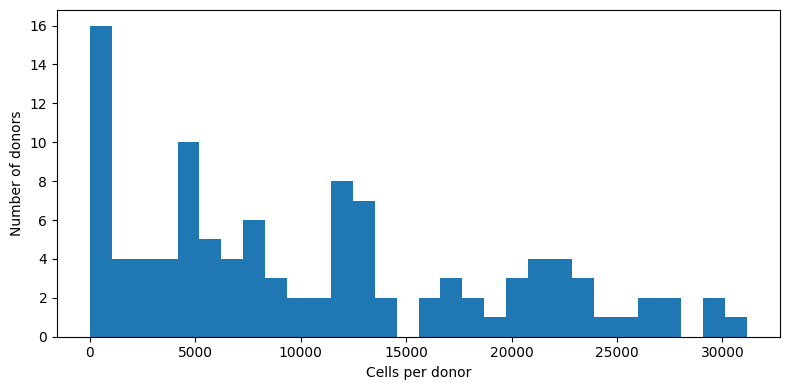

In [31]:
adata.obs['sample'].value_counts().plot(kind='hist', bins=30, figsize=(8, 4))
plt.xlabel('Cells per donor')
plt.ylabel('Number of donors')
plt.tight_layout()
plt.show()



In [36]:
counts = adata.obs.groupby('donor_label')['donor_age_category'].first()
cell_counts = adata.obs['donor_label'].value_counts()

under_5000 = cell_counts[cell_counts < 5000].index
prop_adult = (counts.loc[under_5000] == 'adult').mean()
print(f"{prop_adult:.1%} of donors with <5000 cells are adult")


82.9% of donors with <5000 cells are adult


In [16]:
# Cross-reference DDR panel against degenes
ddr = pd.read_csv('processed_ddr_gene_table.csv')
ddr_ids = ddr[['mouse_symbol','mouse_ensembl_id']]

degene_ids = set(degenes['gene_identifier'].unique())
ddr_ids = ddr_ids.copy()
ddr_ids['in_degenes'] = ddr_ids['mouse_ensembl_id'].isin(degene_ids)

NameError: name 'degenes' is not defined

In [9]:
# Print summary of how many DDR genes are in the aging DEGs, and which ones they are.
print(f"DDR genes in aging degenes: {ddr_ids['in_degenes'].sum()} / {len(ddr_ids)}")

print(ddr_ids[ddr_ids['in_degenes']][['mouse_symbol', 'mouse_ensembl_id']].to_string(index=False))

ddr_genes_in_degenes = ddr_ids[ddr_ids['in_degenes']]['mouse_ensembl_id'].tolist()
degenes[degenes['gene_identifier'].isin(ddr_genes_in_degenes)]

DDR genes in aging degenes: 4 / 85
mouse_symbol   mouse_ensembl_id
       Ercc5 ENSMUSG00000026048
       Rcor1 ENSMUSG00000037896
    Ppargc1a ENSMUSG00000029167
       Terf1 ENSMUSG00000025925


,grouping_type,grouping_label,grouping_name,gene_identifier,gene_symbol,is_primary_ieg,age_effect_size,unadjusted_pvalue,adjusted_pvalue,confidence_interval_higher_bound,confidence_interval_lower_bound
2355,subclass,CS20230722_SUBC_136,136 PMv-TMv Pitx2 Glut,ENSMUSG00000037896,Rcor1,False,-1.847256,1.276871e-07,0.001674,-0.952888,-2.741625
5838,cluster,CS20241021_0331,331_TU-ARH Otp Six6 Gaba_1,ENSMUSG00000029167,Ppargc1a,False,1.236524,1.477188e-08,0.000186,1.728831,0.744218
5874,cluster,CS20241021_0331,331_TU-ARH Otp Six6 Gaba_1,ENSMUSG00000025925,Terf1,False,1.192418,6.142773e-10,0.000008,1.674619,0.710216
6041,cluster,CS20241021_0387,387_PVH-SO-PVa Otp Glut_3,ENSMUSG00000026048,Ercc5,False,-1.645818,4.391507e-07,0.005354,-0.879506,-2.412130
6142,cluster,CS20241021_0395,395_PMv-TMv Pitx2 Glut_3,ENSMUSG00000037896,Rcor1,False,-1.847256,1.276871e-07,0.001674,-0.952888,-2.741625


### **4. Pathway Scoring Methods**
* **Approach 1**: Z-Score and Averaging
* **Approach 2**: Principal Component Analysis
* **Approach 3**: Pseudobulk Principal Component Analysis

* ##### DDR Gene Data Retrieval and Dataset Assembly

In [10]:
gene_names = ddr_ids['mouse_symbol'].dropna().tolist()
print(gene_names)

# Check if the gene symbols are present in the Zeng gene table
available = gene['gene_symbol'].tolist()
missing = [g for g in gene_names if g not in available]
print(f"Available: {len(gene_names) - len(missing)} / {len(gene_names)}")
if missing:
    print(f"Not found in gene table: {missing}")

['Top2b', 'Tdp2', 'Top1', 'Tdp1', 'Parp1', 'Parp2', 'Neil1', 'Neil2', 'Mpg', 'Ogg1', 'Apex1', 'Xrcc1', 'Fen1', 'Pcna', 'Polb', 'Lig3', 'Aptx', 'Pnkp', 'Xpc', 'Ercc1', 'Ercc2', 'Ercc3', 'Gtf2h5', 'Ercc4', 'Ercc5', 'Ercc8', 'Xpa', 'Cetn2', 'Rad23b', 'Polr2a', 'Ercc6', 'Pold1', 'Pole', 'Ddb2', 'Lig1', 'Xrcc5', 'Xrcc6', 'Atp23', 'Prkdc', 'Trp53bp1', 'Dclre1c', 'Polg', 'Xrcc4', 'Nhej1', 'Lig4', 'Atm', 'Mre11a', 'Rad50', 'Nbn', 'Dyrk1a', 'Rbl2', 'E2f4', 'Lin52', 'Rad51', 'Brca1', 'Brca2', 'Rbbp8', 'Swsap1', 'Zswim7', 'Mus81', 'Msh4', 'Mlh1', 'Msh2', 'Msh6', 'Msh3', 'Pms1', 'Pms2', 'Exo1', 'Mlh3', 'Rcor1', 'Phf21a', 'Kdm1a', 'Slx4', 'Slx1b', 'Slx1b', 'Sirt1', 'Ppargc1a', 'Foxo3', 'Sod2', 'Terf1', 'Terf2', 'Tpp1', 'Rap1a', 'Tinf2', 'Pot1a']
Available: 85 / 85
